In [27]:
import pandas as pd
import numpy as np

In [28]:
df = pd.read_csv('accident_cleaned_2021_2025.csv')
print("จำนวนข้อมูลพร้อมใช้งาน:", len(df))
df.head(2)

จำนวนข้อมูลพร้อมใช้งาน: 111409


C:\Users\Asus\AppData\Local\Temp\ipykernel_10072\1821530583.py:1: DtypeWarning: Columns (2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('accident_cleaned_2021_2025.csv')


,ปีที่เกิดเหตุ,วันที่เกิดเหตุ,เวลา,วันที่รายงาน,เวลาที่รายงาน,ACC_CODE,หน่วยงาน,สายทางหน่วยงาน,รหัสสายทาง,สายทาง,...,รถอีแต๋น,รถอื่นๆ,คนเดินเท้า,ผู้เสียชีวิต,ผู้บาดเจ็บสาหัส,ผู้บาดเจ็บเล็กน้อย,รวมจำนวนผู้บาดเจ็บ,เดือน,วันในสัปดาห์,ชั่วโมง
0,2021,2021-01-01,0:00,6/2/2021,9:04,4172437,กรมทางหลวง,ทางหลวง,2044,ร้อยเอ็ด - หนองดง,...,0,0,0,0,0,2,2,1,ศุกร์,0
1,2021,2021-01-01,0:02,1/2/2021,6:31,2918300,กรมทางหลวงชนบท,ทางหลวงชนบท,สน.3054,แยกทางหลวงหมายเลข 223 (กม.ที่ 11+000) - บ้านด่...,...,0,0,0,0,0,1,1,1,ศุกร์,0


In [29]:
df['วันที่เกิดเหตุ'] = pd.to_datetime(df['วันที่เกิดเหตุ'], format='mixed', errors='coerce')
df['เวลา_dt'] = pd.to_datetime(df['เวลา'].astype(str), format='%H:%M', errors='coerce')

In [30]:
df['year'] = df['วันที่เกิดเหตุ'].dt.year
df['month'] = df['วันที่เกิดเหตุ'].dt.month
df['day'] = df['วันที่เกิดเหตุ'].dt.day
df['dayofweek'] = df['วันที่เกิดเหตุ'].dt.dayofweek  # 0=จันทร์, 6=อาทิตย์
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)  # 1=เสาร์-อาทิตย์, 0=จันทร์-ศุกร์
df['hour'] = df['เวลา_dt'].dt.hour

In [31]:
def get_time_period(hour):
    if pd.isna(hour):
        return 'ไม่ระบุ'
    elif 0 <= hour < 4:
        return 'ดึก (00:00 - 03:59)'
    elif 4 <= hour < 8:
        return 'เช้ามืด (04:00 - 07:59)'
    elif 8 <= hour < 12:
        return 'เช้า (08:00 - 11:59)'
    elif 12 <= hour < 16:
        return 'บ่าย (12:00 - 15:59)'
    elif 16 <= hour < 20:
        return 'เย็น (16:00 - 19:59)'
    else:
        return 'กลางคืน (20:00 - 23:59)'

In [32]:
df['time_period'] = df['hour'].apply(get_time_period)

In [33]:
df.drop(columns=['เวลา_dt'], inplace=True) 

In [34]:
df[['วันที่เกิดเหตุ', 'เวลา', 'year', 'month', 'dayofweek', 'is_weekend', 'hour', 'time_period']].head()

,วันที่เกิดเหตุ,เวลา,year,month,dayofweek,is_weekend,hour,time_period
0,2021-01-01,0:00,2021,1,4,0,0.0,ดึก (00:00 - 03:59)
1,2021-01-01,0:02,2021,1,4,0,0.0,ดึก (00:00 - 03:59)
2,2021-01-01,0:05,2021,1,4,0,0.0,ดึก (00:00 - 03:59)
3,2021-01-01,0:05,2021,1,4,0,0.0,ดึก (00:00 - 03:59)
4,2021-01-01,0:05,2021,1,4,0,0.0,ดึก (00:00 - 03:59)


In [35]:
def calculate_severity(row):
    if row['ผู้เสียชีวิต'] >= 1:
        return 'รุนแรงมาก (เสียชีวิต)'
    elif row['ผู้บาดเจ็บสาหัส'] >= 1:
        return 'รุนแรงปานกลาง (บาดเจ็บสาหัส)'
    else:
        return 'รุนแรงน้อย (บาดเจ็บเล็กน้อย/ทรัพย์สินเสียหาย)'

df['severity_level'] = df.apply(calculate_severity, axis=1)

In [36]:
# ดูจำนวนนับของแต่ละระดับความรุนแรง
print(df['severity_level'].value_counts())

# ดูสัดส่วนเป็นเปอร์เซ็นต์ (%)
print("\n--- สัดส่วน (%) ---")
print(df['severity_level'].value_counts(normalize=True) * 100)

severity_level
รุนแรงน้อย (บาดเจ็บเล็กน้อย/ทรัพย์สินเสียหาย)    90868
รุนแรงมาก (เสียชีวิต)                            12218
รุนแรงปานกลาง (บาดเจ็บสาหัส)                      8323
Name: count, dtype: int64

--- สัดส่วน (%) ---
severity_level
รุนแรงน้อย (บาดเจ็บเล็กน้อย/ทรัพย์สินเสียหาย)    81.562531
รุนแรงมาก (เสียชีวิต)                            10.966798
รุนแรงปานกลาง (บาดเจ็บสาหัส)                      7.470671
Name: proportion, dtype: float64


In [37]:
def check_new_year(date):
    if pd.isna(date): return 0
    return 1 if (date.month == 12 and date.day >= 29) or (date.month == 1 and date.day <= 4) else 0

def check_songkran(date):
    if pd.isna(date): return 0
    return 1 if (date.month == 4 and 11 <= date.day <= 17) else 0

df['is_new_year'] = df['วันที่เกิดเหตุ'].apply(check_new_year)
df['is_songkran'] = df['วันที่เกิดเหตุ'].apply(check_songkran)

df['is_dangerous_7days'] = ((df['is_new_year'] == 1) | (df['is_songkran'] == 1)).astype(int)

print("ปีใหม่    :", df['is_new_year'].sum(), "เคส")
print("สงกรานต์  :", df['is_songkran'].sum(), "เคส")
print("รวม 7วันอันตราย:", df['is_dangerous_7days'].sum(), "เคส")

ปีใหม่    : 52235 เคส
สงกรานต์  : 3743 เคส
รวม 7วันอันตราย: 55978 เคส


In [13]:
df.to_csv('accident_processed_data.csv', index=False, encoding='utf-8-sig')

print("บันทึกแล้ว")

บันทึกแล้ว


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('accident_processed_data.csv')

plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.unicode_minus'] = False # ป้องกันเครื่องหมายลบแสดงผลผิดพลาด

sns.set_theme(style="whitegrid", font='Tahoma')

C:\Users\Asus\AppData\Local\Temp\ipykernel_16828\481598657.py:4: DtypeWarning: Columns (2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('accident_processed_data.csv')


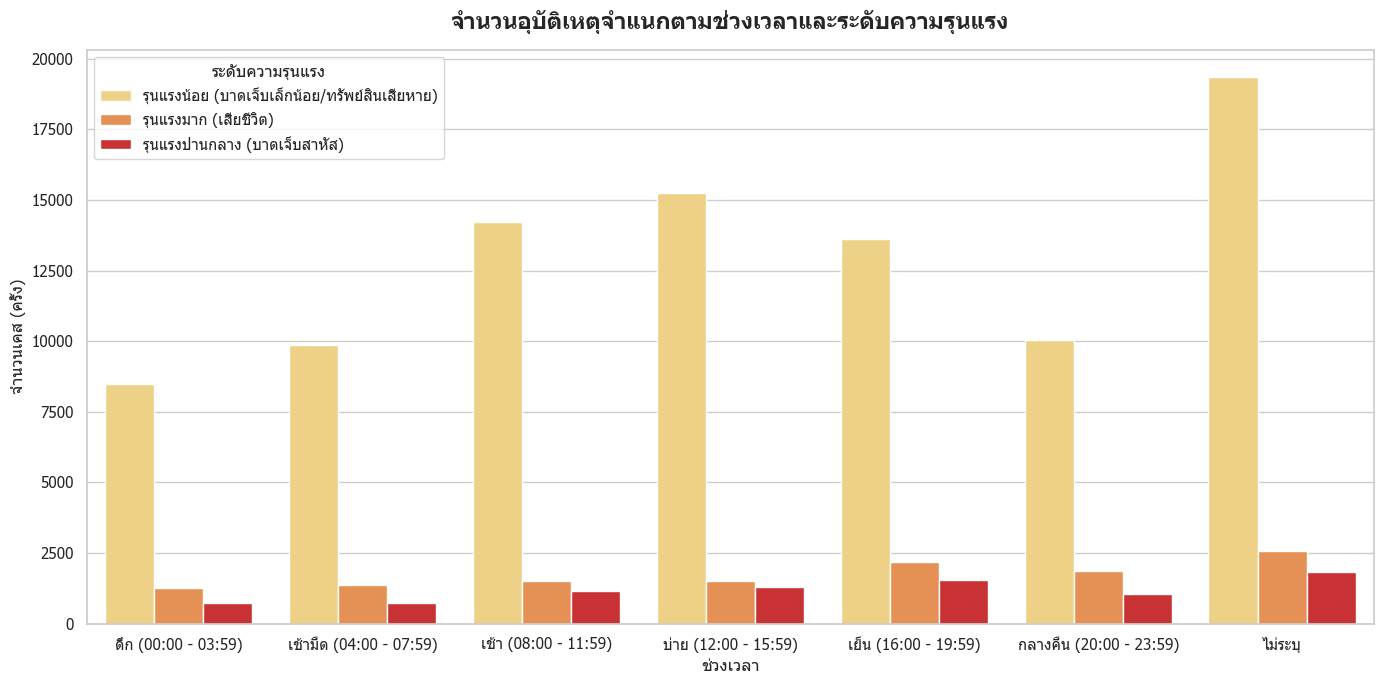

In [15]:
plt.figure(figsize=(14, 7))

ax = sns.countplot(
    data=df, 
    x='time_period', 
    hue='severity_level',
    palette='YlOrRd' 
)

plt.title('จำนวนอุบัติเหตุจำแนกตามช่วงเวลาและระดับความรุนแรง', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('ช่วงเวลา', fontsize=12)
plt.ylabel('จำนวนเคส (ครั้ง)', fontsize=12)
plt.legend(title='ระดับความรุนแรง')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
count_table = pd.crosstab(
    df['time_period'], 
    df['severity_level'], 
    margins=True, 
    margins_name='รวมทั้งหมด'
)
print("==================================================")
display(count_table)

severity_level,รุนแรงน้อย (บาดเจ็บเล็กน้อย/ทรัพย์สินเสียหาย),รุนแรงปานกลาง (บาดเจ็บสาหัส),รุนแรงมาก (เสียชีวิต),รวมทั้งหมด
time_period,,,,
กลางคืน (20:00 - 23:59),10055,1045,1852,12952
ดึก (00:00 - 03:59),8499,717,1250,10466
บ่าย (12:00 - 15:59),15238,1302,1519,18059
เช้า (08:00 - 11:59),14237,1170,1499,16906
เช้ามืด (04:00 - 07:59),9873,741,1360,11974
เย็น (16:00 - 19:59),13616,1537,2185,17338
ไม่ระบุ,19350,1811,2553,23714
รวมทั้งหมด,90868,8323,12218,111409


In [17]:
ct = pd.crosstab(df['time_period'], df['severity_level'], normalize='index') * 100

styled_table = ct.round(2).style.background_gradient(
    subset=['รุนแรงมาก (เสียชีวิต)'], 
    cmap='Reds'
).format('{:.2f}%')

display(styled_table)

severity_level,รุนแรงน้อย (บาดเจ็บเล็กน้อย/ทรัพย์สินเสียหาย),รุนแรงปานกลาง (บาดเจ็บสาหัส),รุนแรงมาก (เสียชีวิต)
time_period,,,
กลางคืน (20:00 - 23:59),77.63%,8.07%,14.30%
ดึก (00:00 - 03:59),81.21%,6.85%,11.94%
บ่าย (12:00 - 15:59),84.38%,7.21%,8.41%
เช้า (08:00 - 11:59),84.21%,6.92%,8.87%
เช้ามืด (04:00 - 07:59),82.45%,6.19%,11.36%
เย็น (16:00 - 19:59),78.53%,8.86%,12.60%
ไม่ระบุ,81.60%,7.64%,10.77%


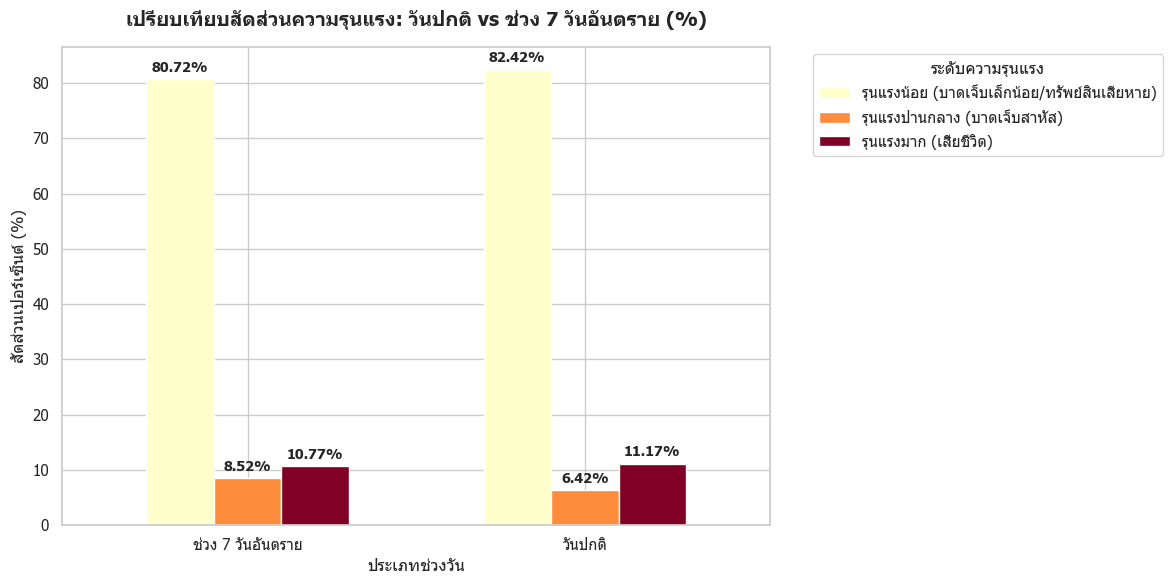

In [18]:
df['dangerous_label'] = df['is_dangerous_7days'].map({0: 'วันปกติ', 1: 'ช่วง 7 วันอันตราย'})

ct_dangerous = pd.crosstab(df['dangerous_label'], df['severity_level'], normalize='index') * 100

ax = ct_dangerous.plot(kind='bar', figsize=(12, 6), colormap='YlOrRd', width=0.6)

plt.title('เปรียบเทียบสัดส่วนความรุนแรง: วันปกติ vs ช่วง 7 วันอันตราย (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('ประเภทช่วงวัน', fontsize=12)
plt.ylabel('สัดส่วนเปอร์เซ็นต์ (%)', fontsize=12)
plt.legend(title='ระดับความรุนแรง', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

In [19]:
df_ny = df[df['is_new_year'] == 1].copy()
df_ny['เทศกาล'] = 'เทศกาลปีใหม่'

df_sk = df[df['is_songkran'] == 1].copy()
df_sk['เทศกาล'] = 'เทศกาลสงกรานต์'

df_compare_fest = pd.concat([df_ny, df_sk])

In [20]:
ct_fest = pd.crosstab(df_compare_fest['เทศกาล'], df_compare_fest['severity_level'], normalize='index') * 100

(array([0, 1]), [Text(0, 0, 'เทศกาลปีใหม่'), Text(1, 0, 'เทศกาลสงกรานต์')])

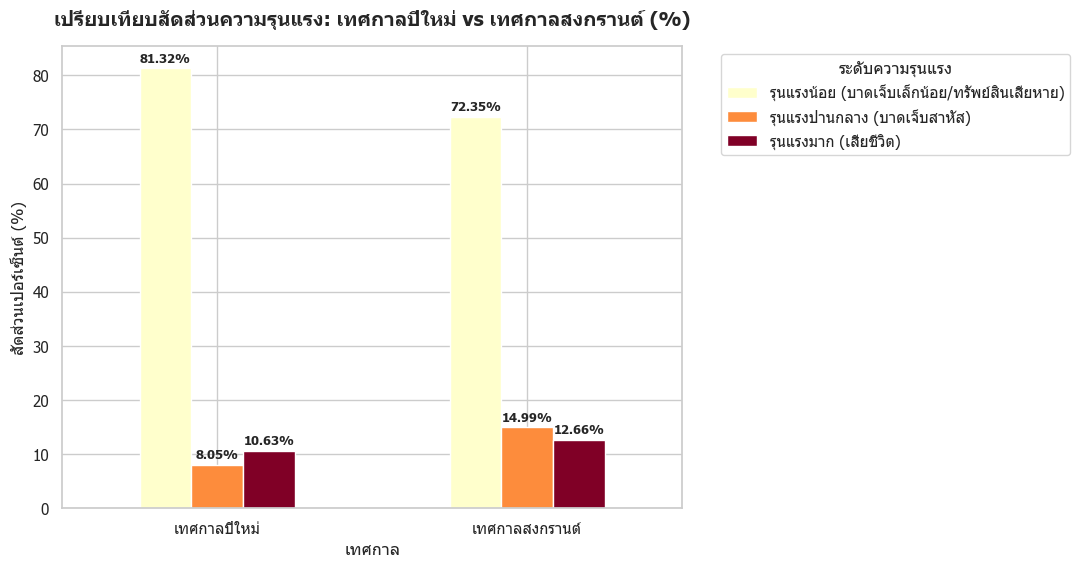

In [22]:
ax = ct_fest.plot(kind='bar', figsize=(8, 6), colormap='YlOrRd', width=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontweight='bold', fontsize=9)
    
plt.title('เปรียบเทียบสัดส่วนความรุนแรง: เทศกาลปีใหม่ vs เทศกาลสงกรานต์ (%)'
          , fontsize=14, fontweight='bold', pad=15)
plt.xlabel('เทศกาล', fontsize=12)
plt.ylabel('สัดส่วนเปอร์เซ็นต์ (%)', fontsize=12)
plt.legend(title='ระดับความรุนแรง', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

In [31]:
df = df.drop_duplicates()

In [38]:
df.head(2)

,ปีที่เกิดเหตุ,วันที่เกิดเหตุ,เวลา,วันที่รายงาน,เวลาที่รายงาน,ACC_CODE,หน่วยงาน,สายทางหน่วยงาน,รหัสสายทาง,สายทาง,...,year,month,day,dayofweek,is_weekend,time_period,severity_level,is_new_year,is_songkran,is_dangerous_7days
0,2021,2021-01-01,0:00,6/2/2021,9:04,4172437,กรมทางหลวง,ทางหลวง,2044,ร้อยเอ็ด - หนองดง,...,2021,1,1,4,0,ดึก (00:00 - 03:59),รุนแรงน้อย (บาดเจ็บเล็กน้อย/ทรัพย์สินเสียหาย),1,0,1
1,2021,2021-01-01,0:02,1/2/2021,6:31,2918300,กรมทางหลวงชนบท,ทางหลวงชนบท,สน.3054,แยกทางหลวงหมายเลข 223 (กม.ที่ 11+000) - บ้านด่...,...,2021,1,1,4,0,ดึก (00:00 - 03:59),รุนแรงน้อย (บาดเจ็บเล็กน้อย/ทรัพย์สินเสียหาย),1,0,1


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111409 entries, 0 to 111408
Data columns (total 52 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ปีที่เกิดเหตุ         111409 non-null  int64         
 1   วันที่เกิดเหตุ        111409 non-null  datetime64[ns]
 2   เวลา                  111409 non-null  object        
 3   วันที่รายงาน          111405 non-null  object        
 4   เวลาที่รายงาน         111401 non-null  object        
 5   ACC_CODE              111409 non-null  int64         
 6   หน่วยงาน              111409 non-null  object        
 7   สายทางหน่วยงาน        111409 non-null  object        
 8   รหัสสายทาง            111399 non-null  object        
 9   สายทาง                111409 non-null  object        
 10  KM                    111055 non-null  float64       
 11  จังหวัด               111409 non-null  object        
 12  รถคันที่1             111409 non-null  object        
 13 

In [46]:
df.to_csv('accident_processed_data.csv', index=False, encoding='utf-8-sig')

print("บันทึกแล้ว")

บันทึกแล้ว


In [38]:
drop_list = [
    'ACC_CODE', 'สายทางหน่วยงาน',  'KM',
    'วันที่เกิดเหตุ', 'เวลา', 'วันที่รายงาน', 'เวลาที่รายงาน', 'hour',
    'ผู้เสียชีวิต', 'ผู้บาดเจ็บสาหัส', 'ผู้บาดเจ็บเล็กน้อย', 'รวมจำนวนผู้บาดเจ็บ',
    'รถและคนที่เกิดเหตุ', 'รถที่เกิดเหตุ', 'dayofweek',
    'ปีที่เกิดเหตุ', 'เดือน', 'วันในสัปดาห์', 'dangerous_label'
]

df_model = df.drop(columns=[col for col in drop_list if col in df.columns])
df_model.to_csv('for_train.csv', index=False, encoding='utf-8-sig')
print("บันทึกแล้ว")

บันทึกแล้ว


In [25]:
drop_list = [
    'ACC_CODE', 'สายทางหน่วยงาน',  'KM','รหัสสายทาง',
    'วันที่เกิดเหตุ', 'เวลา', 'วันที่รายงาน', 'เวลาที่รายงาน', 'hour',
    'รถและคนที่เกิดเหตุ', 'รถที่เกิดเหตุ', 'dayofweek',
    'ปีที่เกิดเหตุ', 'เดือน', 'วันในสัปดาห์', 'dangerous_label','รถจักรยานยนต์',
    'รถสามล้อเครื่อง',
    'รถยนต์นั่งส่วนบุคคล',
    'รถตู้',
    'รถปิคอัพโดยสาร',
    'รถโดยสารมากกว่า4ล้อ',
    'รถปิคอัพบรรทุก4ล้อ',
    'รถบรรทุก6ล้อ',
    'รถบรรทุกไม่เกิน10ล้อ',
    'รถบรรทุกมากกว่า10ล้อ',
    'รถอีแต๋น',
    'รถอื่นๆ',
    'คนเดินเท้า'
]

df2 = df.drop(columns=[col for col in drop_list if col in df.columns])
df2.to_csv('new_accident.csv', index=False, encoding='utf-8-sig')
print("บันทึกแล้ว")

บันทึกแล้ว


In [26]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111409 entries, 0 to 111408
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   หน่วยงาน            111409 non-null  object 
 1   สายทาง              111409 non-null  object 
 2   จังหวัด             111409 non-null  object 
 3   รถคันที่1           111409 non-null  object 
 4   บริเวณที่เกิดเหตุ   111409 non-null  object 
 5   มูลเหตุสันนิษฐาน    111409 non-null  object 
 6   ลักษณะการเกิดเหตุ   111409 non-null  object 
 7   สภาพอากาศ           111409 non-null  object 
 8   LATITUDE            111409 non-null  float64
 9   LONGITUDE           111409 non-null  float64
 10  ผู้เสียชีวิต        111409 non-null  int64  
 11  ผู้บาดเจ็บสาหัส     111409 non-null  int64  
 12  ผู้บาดเจ็บเล็กน้อย  111409 non-null  int64  
 13  รวมจำนวนผู้บาดเจ็บ  111409 non-null  int64  
 14  ชั่วโมง             111409 non-null  int64  
 15  year                111409 non-nul